# ISYE6420: Midterm Exam

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import sympy as sp
import arviz

## Question 1

Calculate definite integral of $\int_{-\infty}^{\infty}e^{-\theta^2}d\theta$ using SymPy

In [2]:
theta = sp.symbols('theta')
func = sp.exp(-theta**2)
# calculate integral with limits from -inf to inf
integral = sp.integrate(func, (theta, -sp.oo, sp.oo))
print(integral)

sqrt(pi)


Calculating $\frac{1}{2\sqrt{\pi}}(\frac{1}{2}+\frac{1}{\sqrt{2}})$

In [3]:
print(round((1/(2*np.sqrt(np.pi)))*(1/2 + 1/(np.sqrt(2))), 4))

0.3405


## Question 2

Evaluating integral: $\int(1-\theta)^{6}d\theta$

In [5]:
theta = sp.symbols('theta')
func = (1-theta)**6
integral = sp.integrate(func, (theta, 0, 1))
print(integral)

1/7


Evaluating the integrals: $d\theta\int_0^1 \theta(1-\theta)^{4} d\theta$ and $\int_0^1 \theta(1-\theta)^{10}$ 

In [6]:
theta = sp.symbols('theta')
func_m = theta*(1-theta)**4
integral_m = sp.integrate(func_m, (theta, 0, 1))
print("Normalising constant of the posterior distribution:", integral_m)

func_numerator = theta*(1-theta)**10
integral_numerator = sp.integrate(func_numerator, (theta, 0, 1))
print("Numerator of posterior predictive is:", integral_numerator)

print("Posterior predictive is:", round(integral_numerator/integral_m, 4))

Normalising constant of the posterior distribution: 1/30
Numerator of posterior predictive is: 1/132
Posterior predictive is: 0.2273


## Question 3

In [ ]:
rng = np.random.default_rng(6420)
y = np.array([-0.9, -0.1, -2.3, 1.7, 1.0, 1.1, 3.1, -0.4, 0.2, 2.4])
n = len(y)

burn_in = 1000
samples = 101000

var_samples = np.zeros((samples, n))  
b_samples = np.zeros(samples)
b = 1

for i in tqdm(range(samples)):
    # Inverse-gamma distribution for each variance
    var = 1/(rng.gamma(shape=10.5, scale=1/((y**2)/2+b)))
    # Gamma distribution for b
    b = rng.gamma(shape=10*n+1, scale=1/(1+(sum(1/var))))
    b_samples[i] = b
    var_samples[i, :] = var

b_posterior = b_samples[burn_in:]
var_posterior = var_samples[burn_in:, :]

100%|██████████| 101000/101000 [00:04<00:00, 22209.58it/s]


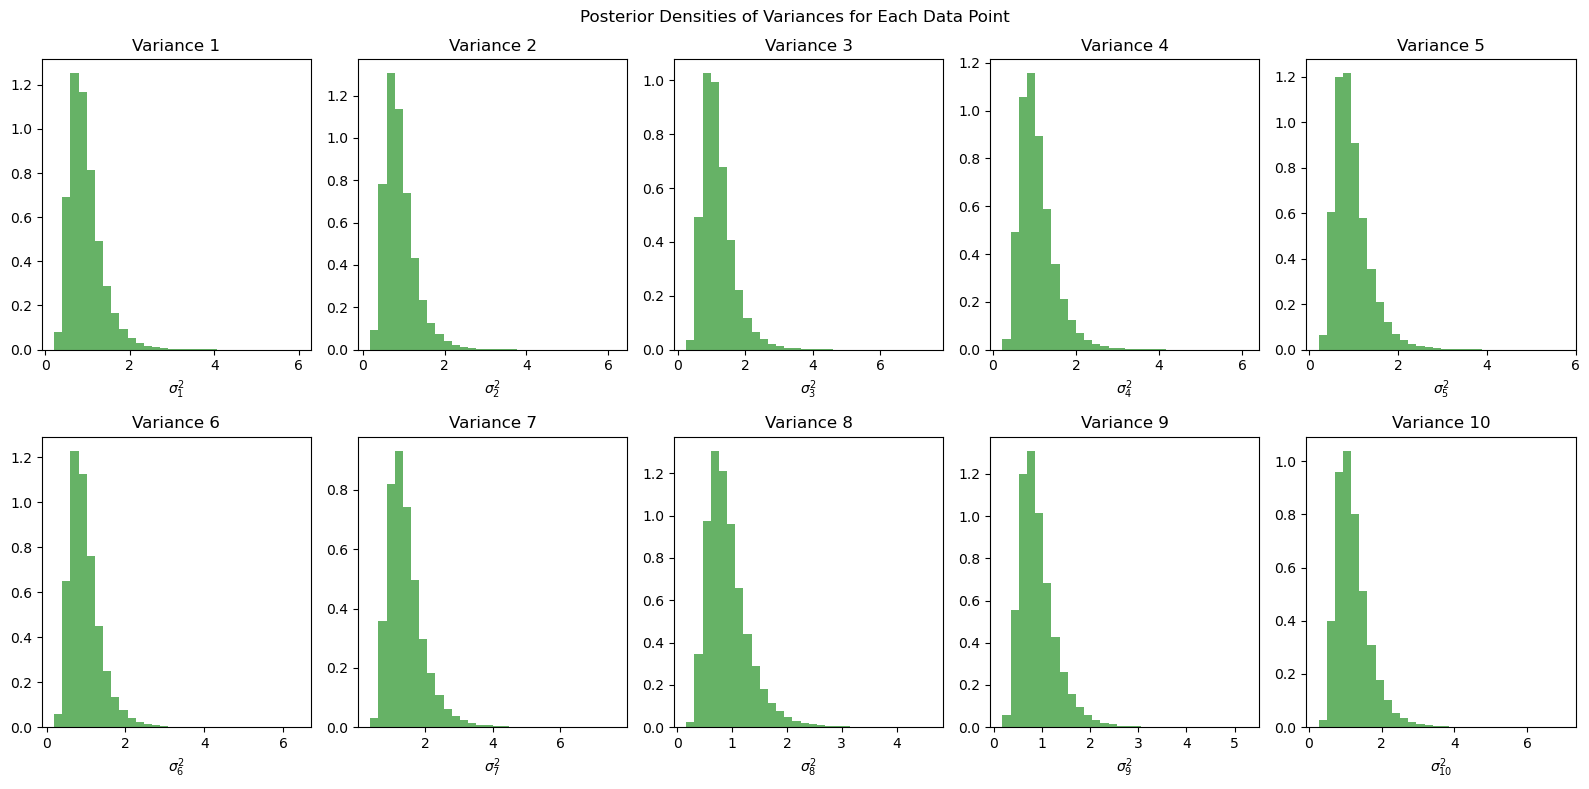

In [110]:
# Plotting posterior densities at each data point
fig, axes = plt.subplots(2, len(y)//2, figsize=(16, 8))
for j in range(len(y)):
    ax = axes[j//5, j%5]
    ax.hist(var_posterior[:, j], bins=30, density=True, alpha=0.6, color='g')
    ax.set_title(f"Variance {j+1}")
    ax.set_xlabel(rf"$\sigma^2_{{{j+1}}}$")


plt.suptitle("Posterior Densities of Variances for Each Data Point")
plt.tight_layout()
plt.show()

In [116]:
# Find posterior mean of all sigma^2
posterior_means = np.mean(var_posterior, axis=0)
print("Posterior means of sigma^2 for each data point:")
for j, mean in enumerate(posterior_means):
    print(f"Sigma_{j+1}: Mean = {mean:.3f}")


Posterior means of sigma^2 for each data point:
Sigma_1: Mean = 0.953
Sigma_2: Mean = 0.909
Sigma_3: Mean = 1.192
Sigma_4: Mean = 1.063
Sigma_5: Mean = 0.963
Sigma_6: Mean = 0.973
Sigma_7: Mean = 1.417
Sigma_8: Mean = 0.919
Sigma_9: Mean = 0.912
Sigma_10: Mean = 1.211


In [119]:
# Find posterior mean of b
posterior_b_means = np.mean(b_posterior, axis=0)
print(f"Posterior mean for b: {posterior_b_means:.3f}")
# HPD 95% credible interval for b
hpd_interval = arviz.hdi(b_posterior, hdi_prob=0.95)
print(f"95% HPD credible interval for b: [{hpd_interval[0]:.3f}, {hpd_interval[1]:.3f}]")

Posterior mean for b: 8.644
95% HPD credible interval for b: [4.968, 12.738]


Text(0, 0.5, 'b value')

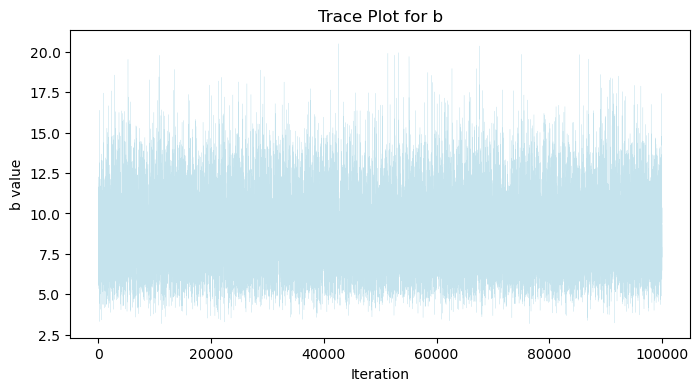

In [123]:
# Plot Trace for validity
plt.figure(figsize=(8, 4))
plt.plot(range(len(b_posterior)), b_posterior, color='lightblue',linewidth=0.2, alpha=0.7)
plt.title('Trace Plot for b')
plt.xlabel('Iteration')
plt.ylabel('b value')